# PDF Corpus EDA — RAG / NLP Track (Milestone 2)

This notebook covers the full EDA pipeline for the PDF corpus used in the MuRIL-based RAG
system: UP government scheme PDFs + any other PDF sources split across **4 folders**.

**Pipeline:**
1. Configuration (folder paths)
2. Build a document inventory (filename, size, page count, folder/source)
3. Extract text (native extraction with pdfplumber, OCR fallback with pytesseract)
4. Corpus-level EDA: page/word counts, language distribution, duplicates, empty extractions, garbage-character ratio, date/year extraction,terminology harmonization,document ctegory justification,integrity verification and version tracking

> Adjust `FOLDER_PATHS` below to point at your 4 actual folders before running.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/DS_AI_RAG_pdfs/

Other_docs  PPQS_Advisories  Schemes  UP_ACP_PDFs


In [3]:
!cp -r "/content/drive/MyDrive/DS_AI_RAG_pdfs/" /content/

In [4]:
!apt-get update -qq
!apt-get install -y poppler-utils

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpoppler-dev libpoppler-private-dev libpoppler118
Recommended packages:
  poppler-data
The following NEW packages will be installed:
  poppler-utils
The following packages will be upgraded:
  libpoppler-dev libpoppler-private-dev libpoppler118
3 upgraded, 1 newly installed, 0 to remove and 88 not upgraded.
Need to get 1,471 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-private-dev amd64 22.02.0-2ubuntu0.13 [198 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-dev amd64 22.02.0-2ubuntu0.13 [5,186 B]
Get:3 http

In [5]:
# Install dependencies (uncomment if running fresh)
!pip install pdfplumber PyMuPDF pytesseract pdf2image langdetect pandas matplotlib seaborn tqdm --break-system-packages
# Note: pytesseract also needs the `tesseract-ocr` binary + `tesseract-ocr-hin` (Hindi) language pack installed at the OS level.
# Note: pdf2image needs `poppler-utils` installed at the OS level.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 94.3 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=f2e5dd6837bd52e6a0d906759df42d14132e44368b0372eb92dbba3c51a35512
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
  Attempting uninstall: Pillow
   

In [6]:
import os
import re
import glob
import hashlib
import warnings
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import pdfplumber
import fitz  # PyMuPDF, used as a fallback / for quick metadata

try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0
    LANGDETECT_AVAILABLE = True
except ImportError:
    LANGDETECT_AVAILABLE = False

try:
    import pytesseract
    from pdf2image import convert_from_path
    OCR_AVAILABLE = True
except ImportError:
    OCR_AVAILABLE = False

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


## 1. Configuration

Point each key at one of your 4 source folders. The folder name becomes the `source` label used throughout the EDA (e.g. to compare corpora by origin).

In [7]:
FOLDER_PATHS = {
    "other_docs":        "/content/DS_AI_RAG_pdfs/Other_docs",
    "ppqs_advisories":     "/content/DS_AI_RAG_pdfs/PPQS_Advisories",
    "schemes":"/content/DS_AI_RAG_pdfs/Schemes",
    "up_acp":"/content/DS_AI_RAG_pdfs/UP_ACP_PDFs"



}

# Where extracted text + outputs will be saved
OUTPUT_DIR = "./pdf_eda_outputs"
TEXT_DIR = os.path.join(OUTPUT_DIR, "extracted_text")
os.makedirs(TEXT_DIR, exist_ok=True)

# OCR is slow -- cap pages OCR'd per doc if a doc is huge (safety valve)
MAX_OCR_PAGES = 30
OCR_DPI = 200


## 2. Build Document Inventory

Walk each folder, collect filename, size, page count, and a content-hash (for later duplicate detection).

In [8]:
def file_hash(path, block_size=65536):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            h.update(block)
    return h.hexdigest()

def get_page_count(path):
    try:
        with fitz.open(path) as doc:
            return doc.page_count
    except Exception:
        return None

records = []
for source, folder in FOLDER_PATHS.items():
    if not os.path.isdir(folder):
        print(f"[WARN] Folder not found, skipping: {folder}")
        continue
    pdf_files = glob.glob(os.path.join(folder, "**", "*.pdf"), recursive=True)
    for path in pdf_files:
        records.append({
            "source": source,
            "filename": os.path.basename(path),
            "filepath": path,
            "size_kb": round(os.path.getsize(path) / 1024, 1),
            "page_count": get_page_count(path),
            "file_hash": file_hash(path),
        })

inventory_df = pd.DataFrame(records)
print(f"Total PDFs found: {len(inventory_df)}")
inventory_df.head()


Total PDFs found: 187


,source,filename,filepath,size_kb,page_count,file_hash
0,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,/content/DS_AI_RAG_pdfs/Other_docs/ICAR-Adviso...,340.7,1,72bce060c89fea887b71c8a6d76b05d666bc1a7541d078...
1,other_docs,Rice-based-cropping-systems.pdf,/content/DS_AI_RAG_pdfs/Other_docs/Rice-based-...,171.1,4,085da2ca25b882a0484a2566757cfc89bacad07e27b51b...
2,other_docs,pop_for_management_of_paddy_blast.pdf,/content/DS_AI_RAG_pdfs/Other_docs/pop_for_man...,141.6,5,edeb0d1e394b36a23be7dcf7dcd9e62e2d35e74b6a42f3...
3,other_docs,EB-52-Wheat-Cultivation-in-India-Pocket-Guide.pdf,/content/DS_AI_RAG_pdfs/Other_docs/EB-52-Wheat...,950.9,40,cbe436b0c8e06360ae61eaa35a0662c85e45c7b6754ae0...
4,other_docs,ICAR-Advisory-March-1-152026.pdf,/content/DS_AI_RAG_pdfs/Other_docs/ICAR-Adviso...,409.0,1,ae2c3962ed11683f7cca00177270f4ec28728f9c243783...


In [9]:
# Exact duplicate check via file hash (catches identical re-uploads across folders)
dupe_hashes = inventory_df["file_hash"].value_counts()
dupe_hashes = dupe_hashes[dupe_hashes > 1]
print(f"Exact-duplicate files (by content hash): {dupe_hashes.sum() - len(dupe_hashes)} redundant copies across {len(dupe_hashes)} groups")

inventory_df["is_exact_duplicate"] = inventory_df["file_hash"].isin(dupe_hashes.index)
inventory_df[inventory_df["is_exact_duplicate"]].sort_values("file_hash")


Exact-duplicate files (by content hash): 2 redundant copies across 2 groups


,source,filename,filepath,size_kb,page_count,file_hash,is_exact_duplicate
25,ppqs_advisories,Advisory on incidence of Fall Army Worm (FAW) ...,/content/DS_AI_RAG_pdfs/PPQS_Advisories/Adviso...,1461.9,2,2f43ff3ca3dc668edd9f78aaa8dd76d944894ade72bbbd...,True
36,ppqs_advisories,Advisory on incidence of Fall Army Worm (FAW) ...,/content/DS_AI_RAG_pdfs/PPQS_Advisories/Adviso...,1461.9,2,2f43ff3ca3dc668edd9f78aaa8dd76d944894ade72bbbd...,True
173,up_acp,FAIZABAD.pdf,/content/DS_AI_RAG_pdfs/UP_ACP_PDFs/FAIZABAD.pdf,1040.0,28,e6813a32c3f1460c62edb889717932d7b6ad65754fe1de...,True
175,up_acp,FIROZABAD.pdf,/content/DS_AI_RAG_pdfs/UP_ACP_PDFs/FIROZABAD.pdf,1040.0,28,e6813a32c3f1460c62edb889717932d7b6ad65754fe1de...,True


In [15]:
# Inspect the duplicate groups properly before deciding what to remove
dupe_groups = inventory_df[inventory_df["is_exact_duplicate"]].sort_values("file_hash")

for h, group in dupe_groups.groupby("file_hash"):
    print(f"\nHash: {h}  ({len(group)} files, size: {group['size_kb'].iloc[0]} KB)")
    print(group[["source", "filename", "size_kb"]].to_string(index=False))


Hash: 2f43ff3ca3dc668edd9f78aaa8dd76d944894ade72bbbde6931225203723e49c  (2 files, size: 1461.9 KB)
         source                                                                                             filename  size_kb
ppqs_advisories Advisory on incidence of Fall Army Worm (FAW) Spodoptera frugiperda on Maize in Himachal Pradesh.pdf   1461.9
ppqs_advisories                     Advisory on incidence of Fall Army Worm (FAW) spodoptera frugiperda on Maize.pdf   1461.9

Hash: e6813a32c3f1460c62edb889717932d7b6ad65754fe1deecad42eca2d697535e  (2 files, size: 1040.0 KB)
source      filename  size_kb
up_acp  FAIZABAD.pdf   1040.0
up_acp FIROZABAD.pdf   1040.0


## 3. Text Extraction (native + OCR fallback)

Strategy per the pdf-reading skill:
- Trying `pdfplumber` first (fast, works for text-native PDFs).
- If extracted text is empty/near-empty (common for scanned government PDFs), fall back to OCR via `pytesseract` on rasterized pages.
- Track `extraction_method` per document

In [16]:
def extract_native_text(path):
    text_parts = []
    try:
        with pdfplumber.open(path) as pdf:
            for page in pdf.pages:
                t = page.extract_text() or ""
                text_parts.append(t)
    except Exception as e:
        return "", f"error: {e}"
    return "\n".join(text_parts), None

def extract_ocr_text(path, max_pages=MAX_OCR_PAGES, dpi=OCR_DPI):
    if not OCR_AVAILABLE:
        return "", "ocr_unavailable"
    try:
        images = convert_from_path(path, dpi=dpi)
    except Exception as e:
        return "", f"error: {e}"
    text_parts = []
    for img in images[:max_pages]:
        # lang='eng+hin' requires the Hindi tesseract language pack installed
        t = pytesseract.image_to_string(img, lang="eng+hin")
        text_parts.append(t)
    return "\n".join(text_parts), None

def is_near_empty(text, min_chars=50):
    return len(text.strip()) < min_chars

extraction_rows = []
for _, row in tqdm(inventory_df.iterrows(), total=len(inventory_df)):
    path = row["filepath"]
    native_text, native_err = extract_native_text(path)
    method = "native"
    err = native_err

    if is_near_empty(native_text):
        ocr_text, ocr_err = extract_ocr_text(path)
        if not is_near_empty(ocr_text):
            native_text = ocr_text
            method = "ocr"
            err = ocr_err
        else:
            method = "failed"
            err = ocr_err or "empty_after_ocr"

    # Save extracted text to disk, one .txt per PDF, mirrored under source folder
    out_dir = os.path.join(TEXT_DIR, row["source"])
    os.makedirs(out_dir, exist_ok=True)
    txt_filename = os.path.splitext(row["filename"])[0] + ".txt"
    out_path = os.path.join(out_dir, txt_filename)
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(native_text)

    extraction_rows.append({
        "filepath": path,
        "extraction_method": method,
        "extraction_error": err,
        "char_count": len(native_text),
        "word_count": len(native_text.split()),
        "text_output_path": out_path,
    })

extraction_df = pd.DataFrame(extraction_rows)
inventory_df = inventory_df.merge(extraction_df, on="filepath", how="left")
inventory_df.head()


100%|██████████| 187/187 [10:15<00:00,  3.29s/it]


,source,filename,filepath,size_kb,page_count,file_hash,is_exact_duplicate,extraction_method,extraction_error,char_count,word_count,text_output_path
0,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,/content/DS_AI_RAG_pdfs/Other_docs/ICAR-Adviso...,340.7,1,72bce060c89fea887b71c8a6d76b05d666bc1a7541d078...,False,ocr,None,2042,356,./pdf_eda_outputs/extracted_text/other_docs/IC...
1,other_docs,Rice-based-cropping-systems.pdf,/content/DS_AI_RAG_pdfs/Other_docs/Rice-based-...,171.1,4,085da2ca25b882a0484a2566757cfc89bacad07e27b51b...,False,native,None,19066,2847,./pdf_eda_outputs/extracted_text/other_docs/Ri...
2,other_docs,pop_for_management_of_paddy_blast.pdf,/content/DS_AI_RAG_pdfs/Other_docs/pop_for_man...,141.6,5,edeb0d1e394b36a23be7dcf7dcd9e62e2d35e74b6a42f3...,False,native,None,6408,1047,./pdf_eda_outputs/extracted_text/other_docs/po...
3,other_docs,EB-52-Wheat-Cultivation-in-India-Pocket-Guide.pdf,/content/DS_AI_RAG_pdfs/Other_docs/EB-52-Wheat...,950.9,40,cbe436b0c8e06360ae61eaa35a0662c85e45c7b6754ae0...,False,native,None,45289,7451,./pdf_eda_outputs/extracted_text/other_docs/EB...
4,other_docs,ICAR-Advisory-March-1-152026.pdf,/content/DS_AI_RAG_pdfs/Other_docs/ICAR-Adviso...,409.0,1,ae2c3962ed11683f7cca00177270f4ec28728f9c243783...,False,ocr,None,2385,415,./pdf_eda_outputs/extracted_text/other_docs/IC...


## 4. Corpus-Level EDA

### 4.1 Summary statistics

In [20]:
summary = inventory_df.groupby("source").agg(
    num_docs=("filename", "count"),
    total_pages=("page_count", "sum"),
    avg_pages=("page_count", "mean"),
    avg_words=("word_count", "mean"),
    ocr_docs=("extraction_method", lambda x: (x == "ocr").sum()),
    failed_docs=("extraction_method", lambda x: (x == "failed").sum()),
).round(1)
summary


,num_docs,total_pages,avg_pages,avg_words,ocr_docs,failed_docs
source,,,,,,
other_docs,12,189,15.8,5818.5,5,0
ppqs_advisories,90,444,4.9,1365.7,9,0
schemes,11,359,32.6,8956.5,0,0
up_acp,74,1805,24.4,4579.7,0,0


### 4.2 Missing / near-empty extraction analysis

In [21]:
failed_df = inventory_df[inventory_df["extraction_method"] == "failed"]
print(f"Documents with failed/near-empty extraction: {len(failed_df)} / {len(inventory_df)}")
failed_df[["source", "filename", "page_count", "char_count"]]


Documents with failed/near-empty extraction: 0 / 187


,source,filename,page_count,char_count


In [22]:
# Final exclusion list -- these are permanently dropped from the RAG corpus
excluded_df = inventory_df[inventory_df["extraction_method"] == "excluded_unreadable"].copy()

print(f"Final excluded (unreadable) documents: {len(excluded_df)}")
excluded_df[["source", "filename", "page_count", "size_kb"]]

# Save the exclusion list separately -- this is your audit trail for Section 11 (Challenges)
excluded_df.to_csv(os.path.join(OUTPUT_DIR, "excluded_unreadable_docs.csv"), index=False)

# Clean corpus = everything except excluded docs
clean_inventory_df = inventory_df[inventory_df["extraction_method"] != "excluded_unreadable"].copy()
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)

print(f"\nFinal clean corpus: {len(clean_inventory_df)} / {len(inventory_df)} documents")

Final excluded (unreadable) documents: 0

Final clean corpus: 187 / 187 documents


### 4.3 Duplicate analysis (exact + near-duplicate)

In [23]:
# Exact duplicates already flagged via file_hash above.
# Near-duplicate check on extracted text (e.g. same circular re-uploaded with a different cover page)
from difflib import SequenceMatcher

def text_similarity(a, b, sample_chars=3000):
    return SequenceMatcher(None, a[:sample_chars], b[:sample_chars]).ratio()

texts = {}
for _, row in inventory_df.iterrows():
    if row["extraction_method"] != "failed" and os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            texts[row["filepath"]] = f.read()

near_dupes = []
paths = list(texts.keys())
for i in range(len(paths)):
    for j in range(i + 1, len(paths)):
        sim = text_similarity(texts[paths[i]], texts[paths[j]])
        if sim > 0.9:
            near_dupes.append((paths[i], paths[j], round(sim, 3)))

near_dupes_df = pd.DataFrame(near_dupes, columns=["file_a", "file_b", "similarity"])
print(f"Near-duplicate pairs found (similarity > 0.90): {len(near_dupes_df)}")
near_dupes_df


Near-duplicate pairs found (similarity > 0.90): 3


,file_a,file_b,similarity
0,/content/DS_AI_RAG_pdfs/PPQS_Advisories/Adviso...,/content/DS_AI_RAG_pdfs/PPQS_Advisories/Adviso...,1.000
1,/content/DS_AI_RAG_pdfs/UP_ACP_PDFs/FARRUKHABA...,/content/DS_AI_RAG_pdfs/UP_ACP_PDFs/PRATAPGARH...,0.901
2,/content/DS_AI_RAG_pdfs/UP_ACP_PDFs/FAIZABAD.pdf,/content/DS_AI_RAG_pdfs/UP_ACP_PDFs/FIROZABAD.pdf,1.000


In [24]:
# Resolve near-duplicates: keep the file with more words per pair (or native over OCR if tied), drop the other
near_dupes_df["a_filename"] = near_dupes_df["file_a"].apply(lambda p: os.path.basename(p))
near_dupes_df["b_filename"] = near_dupes_df["file_b"].apply(lambda p: os.path.basename(p))
near_dupes_df["a_words"] = near_dupes_df["file_a"].map(inventory_df.set_index("filepath")["word_count"])
near_dupes_df["b_words"] = near_dupes_df["file_b"].map(inventory_df.set_index("filepath")["word_count"])

to_drop = set()
for _, row in near_dupes_df.iterrows():
    a, b = row["file_a"], row["file_b"]
    if a in to_drop or b in to_drop:
        continue  # already resolved via a chained duplicate
    if row["a_words"] >= row["b_words"]:
        to_drop.add(b)
    else:
        to_drop.add(a)

print(f"Files marked for removal as near-duplicates: {len(to_drop)}")

inventory_df["is_near_duplicate_dropped"] = inventory_df["filepath"].isin(to_drop)
near_dupe_dropped_df = inventory_df[inventory_df["is_near_duplicate_dropped"]][["source", "filename", "word_count"]]
print(near_dupe_dropped_df)

# Update clean_inventory_df: remove near-duplicates on top of the earlier unreadable exclusion
clean_inventory_df = clean_inventory_df[~clean_inventory_df["filepath"].isin(to_drop)].copy()

# Save updated audit trail
near_dupe_dropped_df.to_csv(os.path.join(OUTPUT_DIR, "excluded_near_duplicate_docs.csv"), index=False)
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)

print(f"\nFinal clean corpus after both exclusions: {len(clean_inventory_df)} / {len(inventory_df)} documents")

Files marked for removal as near-duplicates: 3
              source                                           filename  \
36   ppqs_advisories  Advisory on incidence of Fall Army Worm (FAW) ...   
122           up_acp                                    FARRUKHABAD.pdf   
175           up_acp                                      FIROZABAD.pdf   

     word_count  
36          860  
122        3743  
175        4000  

Final clean corpus after both exclusions: 184 / 187 documents


### 4.4 Language distribution

In [26]:
def detect_language(text, sample_chars=1000):
    sample = text[:sample_chars].strip()
    if not sample:
        return "unknown"
    if LANGDETECT_AVAILABLE:
        try:
            return detect(sample)
        except Exception:
            pass
    # crude fallback: proportion of Devanagari characters
    devanagari = len(re.findall(r"[\u0900-\u097F]", sample))
    return "hi" if devanagari / max(len(sample), 1) > 0.3 else "en"

languages = []
for _, row in clean_inventory_df.iterrows():
    if os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            languages.append(detect_language(f.read()))
    else:
        languages.append("unknown")

clean_inventory_df["detected_language"] = languages
clean_inventory_df["detected_language"].value_counts()


,count
detected_language,
en,182
cy,1
ca,1


### 4.5 Garbage-character / OCR-quality check

In [27]:
def garbage_ratio(text, sample_chars=2000):
    sample = text[:sample_chars]
    if not sample.strip():
        return 1.0
    valid = len(re.findall(r"[a-zA-Z0-9\u0900-\u097F\s.,;:()\-]", sample))
    return round(1 - (valid / len(sample)), 3)

garbage_scores = []
for _, row in clean_inventory_df.iterrows():
    if os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            garbage_scores.append(garbage_ratio(f.read()))
    else:
        garbage_scores.append(None)

clean_inventory_df["garbage_char_ratio"] = garbage_scores
clean_inventory_df[clean_inventory_df["garbage_char_ratio"] > 0.15][["source", "filename", "extraction_method", "garbage_char_ratio"]]


,source,filename,extraction_method,garbage_char_ratio


### 4.6 Document date / freshness check (heuristic)

Looks for a 4-digit year in the filename or extracted text to flag potentially outdated scheme documents.

In [29]:
def extract_year(text_or_name):
    all_years = re.findall(r"\b(19\d{2}|20\d{2})\b", text_or_name)
    return max(map(int, all_years)) if all_years else None

detected_years = []
for _, row in clean_inventory_df.iterrows():
    year = extract_year(row["filename"])
    if year is None and os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            year = extract_year(f.read()[:2000])
    detected_years.append(year)

clean_inventory_df["detected_year"] = detected_years
clean_inventory_df["detected_year"].value_counts(dropna=False).sort_index()


,count
detected_year,
1968.0,1
2007.0,2
2014.0,2
2016.0,1
2017.0,2
2018.0,18
2019.0,10
2020.0,6
2021.0,3


In [30]:
# Inspect the document(s) flagged with implausible years
implausible = clean_inventory_df[
    (clean_inventory_df["detected_year"] > 2026) | (clean_inventory_df["detected_year"] < 1990)
]
print(implausible[["source", "filename", "detected_year"]])

# Check what text triggered the match
for _, row in implausible.iterrows():
    path = row.get("text_output_path")
    if isinstance(path, str) and os.path.exists(path):
        with open(path, encoding="utf-8") as f:
            text = f.read()
        # show context around the detected year
        import re
        match = re.search(r".{40}2027.{40}", text)
        print(f"\n{row['filename']}:")
        print(match.group() if match else "not found in first-pass text")

             source                                           filename  \
49  ppqs_advisories  Advisory on incidence of leaf thrips (Scirtoth...   
75  ppqs_advisories  Grow Safe Food - Beware of Counterfeit, Spurio...   

    detected_year  
49         2027.0  
75         1968.0  

Advisory on incidence of leaf thrips (Scirtothrips dorasalis) and invasive thrips (Thrips parvispinus) to major Chilli growing areas.pdf:
not found in first-pass text

Grow Safe Food - Beware of Counterfeit, Spurious, substandard and unregistered_unlicensed pesticides.pdf:
not found in first-pass text


# 4.7 Word Frequency Analysis

Top 30 most frequent words (stopwords removed):


,word,count
0,water,5303
1,crop,3537
2,rice,3485
3,irrigation,3156
4,soils,2607
5,area,2148
6,use,2055
7,provide,2047
8,cropping,2017
9,measures,1911


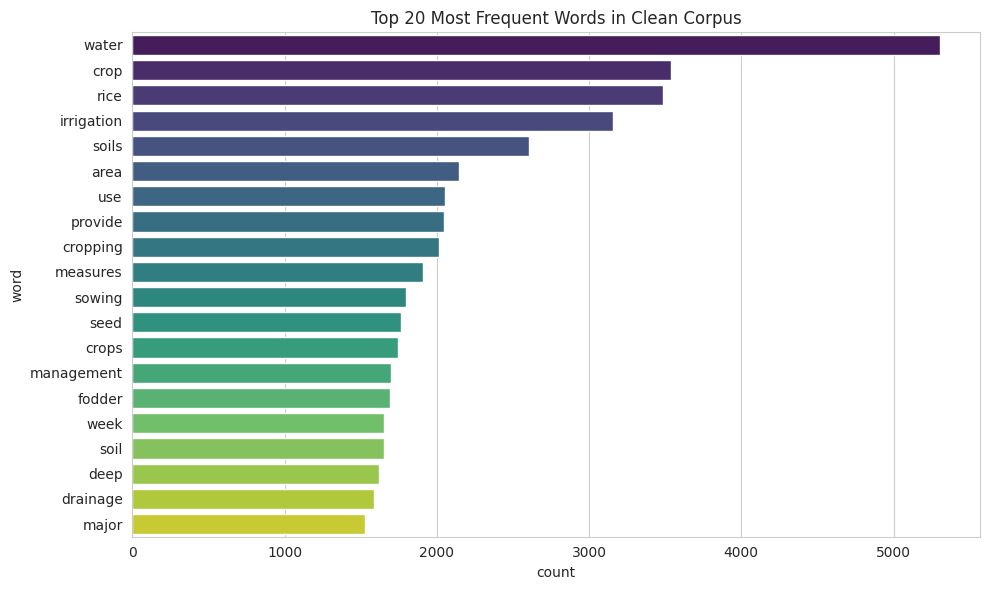

In [31]:
import re
from collections import Counter

ENGLISH_STOPWORDS = set("""
the a an is are was were be been being of to in on for and or with as at by from
this that these those it its it's he she they them his her their we you your i
not no yes will shall can could would should may might must have has had do does did
""".split())

HINDI_STOPWORDS = set("""
और के का की को है हैं था थे थी में से पर एक यह वह इस उस कि जो भी नहीं तो अगर लिए
""".split())

STOPWORDS = ENGLISH_STOPWORDS | HINDI_STOPWORDS

def tokenize(text):
    tokens = re.findall(r"[a-zA-Z\u0900-\u097F]+", text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

all_tokens = []
for _, row in clean_inventory_df.iterrows():
    if os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            all_tokens.extend(tokenize(f.read()))

word_freq = Counter(all_tokens)
top_words_df = pd.DataFrame(word_freq.most_common(30), columns=["word", "count"])
print("Top 30 most frequent words (stopwords removed):")
display(top_words_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df.head(20), x="count", y="word", palette="viridis")
plt.title("Top 20 Most Frequent Words in Clean Corpus")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "word_frequency.png"), dpi=150)
plt.show()



## 4.8 Document Category Justification ("Why These PDFs")

TA feedback: *"The rationale for selecting the final datasets is not sufficiently justified."*

Each document is tagged with one of four functional categories, matched against the project's
Rice/Wheat/UP scope from Milestone 1. This turns the corpus from an unexplained list of 187
PDFs into a set of documents each justified by an explicit inclusion rule.

**Inclusion criteria (all four must hold for a document to be in-corpus):**
1. Official government / institutional origin (Union or UP State portals, ICAR, RBI, PPQS)
2. Directly relevant to Rice and/or Wheat cultivation, or to a scheme a UP farmer could access
3. Falls into one of the four functional categories below
4. Not a duplicate/superseded version of an already-included document

**Rejected alternatives (and why):**
- General agricultural blogs / web-scraped articles — unverifiable authorship, no authority
- Secondary summaries (e.g. news coverage of a scheme) — risk of inaccuracy vs. primary source
- Non-UP state scheme/advisory documents — out of the project's UP-only scope (Milestone 1)
- Cash-crop-only circulars (e.g. sugarcane-exclusive) — out of the Rice/Wheat scope

In [32]:
def categorize_document(source, filename):
    """Assigns a functional category + one-line rationale per document.
    Folder is the primary signal; filename keywords refine `other_docs` (mixed folder).
    """
    fname_lower = filename.lower()

    if source == "schemes":
        return "scheme_eligibility", "UP/Union scheme document defining farmer eligibility, benefits, or subsidy terms."
    if source == "ppqs_advisories":
        return "crop_advisory", "PPQS pest/disease management advisory — addresses dosage-hallucination risk (Milestone 1)."
    if source == "up_acp":
        return "contingency_plan", "UP district-level Agriculture Contingency Plan — regional planning/advisory content."

    # other_docs is a mixed folder -- classify by filename keywords
    scheme_kw = ["scheme", "guideline", "kisan", "subvention", "yojana", "credit card", "bima"]
    advisory_kw = ["advisory", "blast", "pest", "disease", "cropping", "wheat", "rice", "paddy", "pop_for"]

    if any(kw in fname_lower for kw in scheme_kw):
        return "scheme_eligibility", "Central scheme guideline (matched via filename) — policy/eligibility content."
    if any(kw in fname_lower for kw in advisory_kw):
        return "crop_advisory", "Crop-specific advisory/practice guide (matched via filename)."
    return "policy_guideline", "General agricultural policy/reference document (ICAR magazine, cultivation guide, etc.)."

clean_inventory_df[["doc_category", "category_rationale"]] = clean_inventory_df.apply(
    lambda row: pd.Series(categorize_document(row["source"], row["filename"])), axis=1
)

print("Document category breakdown:")
print(clean_inventory_df["doc_category"].value_counts())
clean_inventory_df[["source", "filename", "doc_category", "category_rationale"]].head(10)

Document category breakdown:
doc_category
crop_advisory         97
contingency_plan      72
scheme_eligibility    11
policy_guideline       4
Name: count, dtype: int64


,source,filename,doc_category,category_rationale
0,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
1,other_docs,Rice-based-cropping-systems.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
2,other_docs,pop_for_management_of_paddy_blast.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
3,other_docs,EB-52-Wheat-Cultivation-in-India-Pocket-Guide.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
4,other_docs,ICAR-Advisory-March-1-152026.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
5,other_docs,National_Mission_on_Natural_Farming.pdf,policy_guideline,General agricultural policy/reference document...
6,other_docs,Indian_Farming_November_2025.pdf,policy_guideline,General agricultural policy/reference document...
7,other_docs,CMP_Circulars_29102025_638973560481999250_Rabi...,policy_guideline,General agricultural policy/reference document...
8,other_docs,ICAR-Advisory-WHEAT-April-16-302026.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
9,other_docs,ICAR-Advisory-FOR-SOWING-March-16-312026.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...


In [33]:
category_by_source = pd.crosstab(clean_inventory_df["source"], clean_inventory_df["doc_category"])
print("Category distribution by source folder (sanity check -- confirms folder-category alignment):")
category_by_source

Category distribution by source folder (sanity check -- confirms folder-category alignment):


doc_category,contingency_plan,crop_advisory,policy_guideline,scheme_eligibility
source,,,,
other_docs,0,8,4,0
ppqs_advisories,0,89,0,0
schemes,0,0,0,11
up_acp,72,0,0,0


## 4.9 Terminology Harmonization (Crop / District / Agricultural Terms)

TA feedback: *"There is little discussion of standardizing: crop names, district names, scheme
names, agricultural terminology across different document sources."*

This section builds a **data-driven candidate list** of terminology variants found in the
corpus (e.g. "paddy" vs "rice", old district names vs current ones post-bifurcation), matched
against two reference lists:
- A canonical **crop name list** (aligned with the Yield subsystem's crop vocabulary)
- The official **75-district UP list** (post-1997 bifurcations included, e.g. Ayodhya/Faizabad)

**Nothing is auto-applied.** Every candidate is exported for manual review; only entries a
human confirms are moved into `VALIDATED_ALIASES` and actually applied to the text.

In [44]:
# --- FINAL: Curated terminology harmonization (dictionary-only, no algorithmic discovery) ---
# Rationale: semantic (word2vec) and fuzzy-spelling discovery were both tested and found
# unreliable at this corpus size (184 docs) -- word2vec produced near-random similarity
# scores due to insufficient training data, and fuzzy-spelling matched on coincidental
# character overlap (e.g. "area"~"agra"). A hand-curated dictionary is the reliable
# approach at this scale.

VALIDATED_ALIASES = {
    # Crop name variants (Hindi/Hinglish -> canonical English, matching Yield subsystem vocabulary)
    "paddy": "rice", "dhan": "rice", "chawal": "rice",
    "gehun": "wheat", "gehu": "wheat", "kanak": "wheat",
    "makka": "maize", "makai": "maize", "bhutta": "maize",
    "chana": "gram", "til": "sesame", "sarson": "mustard",
    "urad": "urad", "urd": "urad",  # normalize spelling variant

    # District renames / historical names (post-bifurcation and colloquial names)
     # 2018 Yogi Adityanath government renames (most likely to appear in recent scheme PDFs)
    "allahabad": "prayagraj",       # renamed Oct 2018, ahead of 2019 Kumbh Mela
    "faizabad": "ayodhya",          # renamed Nov 2018 (district + division)

    # 2011-12 back-and-forth: Mayawati govt (BSP) created these with new names in 2011,
    # then Akhilesh Yadav govt (SP) reverted them to historical/older names in 2012.
    # Both name variants may appear in older PDFs depending on publication date.
    "prabuddh nagar": "shamli",
    "prabudh nagar": "shamli",           # spelling variant seen in some sources
    "bhim nagar": "sambhal",
    "panchsheel nagar": "hapur",
    "jyotiba phule nagar": "amroha",
    "jyotibaphule nagar": "amroha",       # spelling variant (no space)
    "kanshi ram nagar": "kasganj",
    "kanshiram nagar": "kasganj",         # spelling variant (no space)
    "chhatrapati shahuji maharaj nagar": "amethi",
    "chatrapati sahuji maharaj nagar": "amethi",  # common spelling variant
    "mahamaya nagar": "hathras",

    # Kanpur Dehat had TWO renames: 2010 -> Ramabai Nagar, then reverted 2012 -> Kanpur Dehat.
    # Include both directions since older PDFs may use either name.
    "ramabai nagar": "kanpur dehat",
    "rama bai nagar": "kanpur dehat",     # spelling variant

    # Common colloquial/historical name still used in some documents
    "banaras": "varanasi",
    "kashi": "varanasi",
    "bhadohi": "sant ravidas nagar",
}

def apply_harmonization(text, alias_map):
    for variant, canonical in alias_map.items():
        text = re.sub(rf"\b{re.escape(variant)}\b", canonical, text, flags=re.IGNORECASE)
    return text

# Quantify impact across the clean corpus
impact_rows = []
for variant, canonical in VALIDATED_ALIASES.items():
    count = 0
    for _, row in clean_inventory_df.iterrows():
        path = row.get("text_output_path")
        if isinstance(path, str) and os.path.exists(path):
            with open(path, encoding="utf-8") as f:
                count += len(re.findall(rf"\b{re.escape(variant)}\b", f.read(), flags=re.IGNORECASE))
    impact_rows.append({"variant": variant, "canonical": canonical, "occurrences_merged": count})

impact_df = pd.DataFrame(impact_rows).sort_values("occurrences_merged", ascending=False)
impact_df.to_csv(os.path.join(OUTPUT_DIR, "harmonization_impact_report.csv"), index=False)

# Write harmonized text (kept separate from raw extraction)
HARMONIZED_DIR = os.path.join(OUTPUT_DIR, "extracted_text_harmonized")
harmonized_paths = []
for _, row in clean_inventory_df.iterrows():
    path = row.get("text_output_path")
    if not isinstance(path, str) or not os.path.exists(path):
        harmonized_paths.append(None)
        continue
    with open(path, encoding="utf-8") as f:
        text = f.read()
    harmonized_text = apply_harmonization(text, VALIDATED_ALIASES)
    out_dir = os.path.join(HARMONIZED_DIR, row["source"])
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, os.path.basename(path))
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(harmonized_text)
    harmonized_paths.append(out_path)

clean_inventory_df["harmonized_text_path"] = harmonized_paths

print(f"Validated aliases applied: {len(VALIDATED_ALIASES)}")
print(f"Total occurrences merged: {impact_df['occurrences_merged'].sum()}")
print(f"Harmonized text written for {clean_inventory_df['harmonized_text_path'].notna().sum()} documents.")
impact_df

Validated aliases applied: 32
Total occurrences merged: 984
Harmonized text written for 184 documents.


,variant,canonical,occurrences_merged
13,urd,urad,382
0,paddy,rice,262
1,dhan,rice,94
15,faizabad,ayodhya,84
10,til,sesame,74
14,allahabad,prayagraj,30
6,makka,maize,21
29,banaras,varanasi,11
31,bhadohi,sant ravidas nagar,10
21,jyotibaphule nagar,amroha,7


In [45]:
# --- Consolidate: overwrite extracted text in-place with harmonized version ---
# Rationale: keeping raw-extraction and harmonized-text as two separate folders adds
# confusion with no real benefit here -- the raw extraction is already preserved via
# the original source PDFs + the SHA-256 integrity manifest (Section 4.10), so a
# second "raw text" copy is redundant. Going forward there is ONE final text file
# per document, and chunking reads from it directly.

FINAL_TEXT_DIR = os.path.join(OUTPUT_DIR, "extracted_text_final")

final_paths = []
for _, row in clean_inventory_df.iterrows():
    raw_path = row.get("text_output_path")
    if not isinstance(raw_path, str) or not os.path.exists(raw_path):
        final_paths.append(None)
        continue

    with open(raw_path, encoding="utf-8") as f:
        text = f.read()

    harmonized_text = apply_harmonization(text, VALIDATED_ALIASES)

    out_dir = os.path.join(FINAL_TEXT_DIR, row["source"])
    os.makedirs(out_dir, exist_ok=True)
    final_path = os.path.join(out_dir, os.path.basename(raw_path))
    with open(final_path, "w", encoding="utf-8") as f:
        f.write(harmonized_text)

    final_paths.append(final_path)

clean_inventory_df["final_text_path"] = final_paths

# Drop the now-redundant harmonized-only column/folder if it exists from the previous run
if "harmonized_text_path" in clean_inventory_df.columns:
    clean_inventory_df = clean_inventory_df.drop(columns=["harmonized_text_path"])

print(f"Final harmonized text written for {clean_inventory_df['final_text_path'].notna().sum()} documents.")
print(f"Location: {FINAL_TEXT_DIR}")
print("\nUse `final_text_path` as the single source for chunking going forward.")

# Save the updated inventory with the single final path column
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)

Final harmonized text written for 184 documents.
Location: ./pdf_eda_outputs/extracted_text_final

Use `final_text_path` as the single source for chunking going forward.


## 4.10 Integrity Verification & Version Tracking

TA feedback: *"No checksum or integrity verification is mentioned"* and *"Dataset download
dates are not recorded... Dataset versions are not recorded."*

The SHA-256 `file_hash` computed in Section 2 already serves as a per-document integrity
checksum (unchanged since collection = same hash). This section makes that explicit, and adds
the download-date / pipeline-version metadata needed for reproducibility.

In [47]:
import hashlib

SOURCE_SNAPSHOT_DATE = "2026-07-10"
PIPELINE_VERSION = "milestone2_v3_harmonized"  # bump this string whenever the pipeline logic changes

def file_sha256(path, block_size=65536):
    """SHA-256 checksum of a file's raw bytes -- detects any change/corruption."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            h.update(block)
    return h.hexdigest()

# 1. Checksum of the ORIGINAL source PDF (proves the raw source hasn't changed/been swapped)
clean_inventory_df["source_pdf_sha256"] = clean_inventory_df["filepath"].apply(
    lambda p: file_sha256(p) if isinstance(p, str) and os.path.exists(p) else None
)

# 2. Checksum of the FINAL processed text (proves this exact processed output is what's referenced)
clean_inventory_df["final_text_sha256"] = clean_inventory_df["final_text_path"].apply(
    lambda p: file_sha256(p) if isinstance(p, str) and os.path.exists(p) else None
)

# 3. Record when this snapshot was collected and which pipeline version produced it
clean_inventory_df["download_date"] = SOURCE_SNAPSHOT_DATE
clean_inventory_df["pipeline_version"] = PIPELINE_VERSION

# 4. Exporing a standalone integrity manifest -- the single source of truth for verification
integrity_manifest = clean_inventory_df[[
    "source", "filename", "source_pdf_sha256", "final_text_sha256",
    "size_kb", "download_date", "pipeline_version"
]].copy()

manifest_path = os.path.join(OUTPUT_DIR, "integrity_manifest.csv")
integrity_manifest.to_csv(manifest_path, index=False)

# 5. Save the updated master inventory too, so checksums travel with the rest of the metadata
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)

print(f"Integrity manifest saved: {manifest_path}")
print(f"Documents covered: {len(integrity_manifest)}")
print(f"Snapshot date: {SOURCE_SNAPSHOT_DATE} | Pipeline version: {PIPELINE_VERSION}")
integrity_manifest.head()

Integrity manifest saved: ./pdf_eda_outputs/integrity_manifest.csv
Documents covered: 184
Snapshot date: 2026-07-10 | Pipeline version: milestone2_v3_harmonized


,source,filename,source_pdf_sha256,final_text_sha256,size_kb,download_date,pipeline_version
0,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,72bce060c89fea887b71c8a6d76b05d666bc1a7541d078...,a3a882f9bb55ad9f892e0808a92efe6113ac4d2a1671cc...,340.7,2026-07-10,milestone2_v3_harmonized
1,other_docs,Rice-based-cropping-systems.pdf,085da2ca25b882a0484a2566757cfc89bacad07e27b51b...,8a2ca286544d82ce25bdca97c74679227a6dc78bffda65...,171.1,2026-07-10,milestone2_v3_harmonized
2,other_docs,pop_for_management_of_paddy_blast.pdf,edeb0d1e394b36a23be7dcf7dcd9e62e2d35e74b6a42f3...,edaf91ee20cf14bc104309de69de2df605ec66c05a06f1...,141.6,2026-07-10,milestone2_v3_harmonized
3,other_docs,EB-52-Wheat-Cultivation-in-India-Pocket-Guide.pdf,cbe436b0c8e06360ae61eaa35a0662c85e45c7b6754ae0...,88cc31cba5d69127af879fe8cf25eb10201220a304e986...,950.9,2026-07-10,milestone2_v3_harmonized
4,other_docs,ICAR-Advisory-March-1-152026.pdf,ae2c3962ed11683f7cca00177270f4ec28728f9c243783...,f73de539b3aaecbc728698b105690ec6ed1162e4048476...,409.0,2026-07-10,milestone2_v3_harmonized


In [54]:
check_df = pd.read_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"))
print(check_df.columns.tolist())

['source', 'filename', 'filepath', 'size_kb', 'page_count', 'file_hash', 'is_exact_duplicate', 'extraction_method', 'extraction_error', 'char_count', 'word_count', 'detected_language', 'garbage_char_ratio', 'detected_year', 'doc_category', 'category_rationale', 'final_text_path', 'source_pdf_sha256', 'final_text_sha256', 'download_date', 'pipeline_version']


In [52]:
clean_inventory_df = clean_inventory_df.drop(columns=["text_output_path"])
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)

In [53]:
clean_inventory_df['final_text_path']

,final_text_path
0,./pdf_eda_outputs/extracted_text_final/other_d...
1,./pdf_eda_outputs/extracted_text_final/other_d...
2,./pdf_eda_outputs/extracted_text_final/other_d...
3,./pdf_eda_outputs/extracted_text_final/other_d...
4,./pdf_eda_outputs/extracted_text_final/other_d...
...,...
182,./pdf_eda_outputs/extracted_text_final/up_acp/...
183,./pdf_eda_outputs/extracted_text_final/up_acp/...
184,./pdf_eda_outputs/extracted_text_final/up_acp/...
185,./pdf_eda_outputs/extracted_text_final/up_acp/...


In [ ]:
clean_inventory_df = clean_inventory_df.drop(columns=["text_output_path"])
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)